In [ ]:

import os, json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import albumentations as A

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU ready: {gpus[0].name}')
else:
    print('No GPU found — training on CPU (slower). Run nvidia-smi to check.')
print(f'TensorFlow: {tf.__version__}')

No GPU found — training on CPU (slower). Run nvidia-smi to check.
TensorFlow: 2.21.0


In [ ]:

BASE_DIR    = r'D:/FYP/dental-vision/ML/data/processed'
TRAIN_DIR   = os.path.join(BASE_DIR, 'train')
VAL_DIR     = os.path.join(BASE_DIR, 'valid')
TEST_DIR    = os.path.join(BASE_DIR, 'test')
MODEL_DIR   = r'D:/FYP/dental-vision/ML/Models'
os.makedirs(MODEL_DIR, exist_ok=True)
IMG_SIZE    = 224
BATCH_SIZE  = 32       
EPOCHS      = 40       
NUM_CLASSES = 5
LR          = 1e-3
MODEL_SAVE  = os.path.join(MODEL_DIR, 'dental_model_v3_focal.keras')
print('Config ready.')
print(f'  Train : {TRAIN_DIR}')
print(f'  Val   : {VAL_DIR}')
print(f'  Test  : {TEST_DIR}')
print(f'  Save  : {MODEL_SAVE}')

Config ready.
  Train : D:/FYP/dental-vision/ML/data/processed\train
  Val   : D:/FYP/dental-vision/ML/data/processed\valid
  Test  : D:/FYP/dental-vision/ML/data/processed\test
  Save  : D:/FYP/dental-vision/ML/Models\dental_model_v3_focal.keras


In [ ]:

xray_augment = A.Compose([
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.GaussNoise(var_limit=(5, 20), p=0.3),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.5),
])

def albumentations_augment(image):
    """Preprocessing function for ImageDataGenerator.
    Receives uint8 image BEFORE rescale, returns float32.
    rescale=1/255 is applied after this by Keras.
    """
    image = image.astype(np.uint8)
    return xray_augment(image=image)['image'].astype(np.float32)

print('Augmentation pipeline ready.')
print('  CLAHE, brightness/contrast, gaussian noise, flip, shift/scale/rotate')

Augmentation pipeline ready.
  CLAHE, brightness/contrast, gaussian noise, flip, shift/scale/rotate


C:\Users\HP\AppData\Local\Temp\ipykernel_2908\3006647279.py:8: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5, 20), p=0.3),
d:\FYP\dental-vision\venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:

train_datagen = ImageDataGenerator(rescale=1.0/255.0, preprocessing_function=albumentations_augment)
val_datagen   = ImageDataGenerator(rescale=1.0/255.0)
test_datagen  = ImageDataGenerator(rescale=1.0/255.0)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True, seed=42)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

# Force consistent class ordering — sorted alphabetically
class_names = sorted(train_generator.class_indices.keys())
with open(os.path.join(MODEL_DIR, 'class_names.json'), 'w') as f:
    json.dump(class_names, f)

print(f'Classes ({len(class_names)}): {class_names}')
print(f'Train steps: {len(train_generator)} | Val steps: {len(val_generator)} | Test steps: {len(test_generator)}')

Found 15029 images belonging to 5 classes.
Found 3970 images belonging to 5 classes.
Found 2094 images belonging to 5 classes.
Classes (5): ['Bone_Loss', 'Caries', 'Impacted_Tooth', 'Missing_Teeth', 'Periapical_Lesion']
Train steps: 470 | Val steps: 125 | Test steps: 66


In [ ]:

print('Class distribution in training set:\n')
counts = np.bincount(train_generator.classes)
total  = len(train_generator.classes)
for i, (name, count) in enumerate(zip(class_names, counts)):
    bar = '|' * int(count / total * 40)
    print(f'  [{i}] {name:<25s} {count:5d} ({100*count/total:5.1f}%)  {bar}')

ratio = counts.max() / counts.min()
print(f'\n  Imbalance ratio: {ratio:.1f}x (largest / smallest)')

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(weights))
print('\nClass weights (higher = rarer class):')
for idx, w in class_weight_dict.items():
    print(f'  [{idx}] {class_names[idx]:<25s} {w:.3f}')

Class distribution in training set:

  [0] Bone_Loss                  1964 ( 13.1%)  |||||
  [1] Caries                     2182 ( 14.5%)  |||||
  [2] Impacted_Tooth             7655 ( 50.9%)  ||||||||||||||||||||
  [3] Missing_Teeth              1230 (  8.2%)  |||
  [4] Periapical_Lesion          1998 ( 13.3%)  |||||

  Imbalance ratio: 6.2x (largest / smallest)

Class weights (higher = rarer class):
  [0] Bone_Loss                 1.530
  [1] Caries                    1.378
  [2] Impacted_Tooth            0.393
  [3] Missing_Teeth             2.444
  [4] Periapical_Lesion         1.504


In [ ]:

alpha_array = np.array([class_weight_dict[i] for i in range(NUM_CLASSES)], dtype='float32')
alpha_array = alpha_array / alpha_array.sum() * NUM_CLASSES 

def categorical_focal_loss(alpha, gamma=2.0):
    alpha_t = tf.constant(alpha, dtype=tf.float32)
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha_t * tf.pow(1 - y_pred, gamma)
        return tf.reduce_sum(weight * cross_entropy, axis=-1)
    return loss_fn

print(f'Focal loss ready.')
print(f'  Alpha (normalised): {np.round(alpha_array, 3)}')
print(f'  Gamma: 2.0')

Focal loss ready.
  Alpha (normalised): [1.056 0.95  0.271 1.686 1.038]
  Gamma: 2.0


In [ ]:

def residual_block(x, filters, stride=1):
    shortcut = x
    x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x

def build_dental_cnn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    # Stem: 224x224 -> 56x56
    x = layers.Conv2D(32, 7, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)
    # Residual stages
    x = residual_block(x, 64);  x = residual_block(x, 64)
    x = residual_block(x, 128, stride=2); x = residual_block(x, 128)
    x = residual_block(x, 256, stride=2); x = residual_block(x, 256); x = residual_block(x, 256)
    x = residual_block(x, 512, stride=2); x = residual_block(x, 512)
    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name='DentalCNN_ResNet')

model = build_dental_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES)
model.compile(
    optimizer=Adam(learning_rate=LR, clipnorm=1.0),
    loss=categorical_focal_loss(alpha_array, gamma=2.0),
    metrics=['accuracy']
)
print(f'Model built: {model.count_params():,} parameters')
print(f'  Optimizer : Adam (LR={LR}, clipnorm=1.0)')
print(f'  Loss      : focal loss (gamma=2.0)')
print(f'  No pretrained weights')

Model built: 12,479,461 parameters
  Optimizer : Adam (LR=0.001, clipnorm=1.0)
  Loss      : focal loss (gamma=2.0)
  No pretrained weights


In [ ]:

def cosine_lr_schedule(epoch, total_epochs=EPOCHS, lr_max=LR, lr_min=1e-6):
    return lr_min + 0.5 * (lr_max - lr_min) * (1 + np.cos(np.pi * epoch / total_epochs))

training_callbacks = [
    callbacks.ModelCheckpoint(
        filepath=MODEL_SAVE, monitor='val_accuracy',
        save_best_only=True, verbose=1),
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1),
    callbacks.LearningRateScheduler(
        lambda epoch: cosine_lr_schedule(epoch), verbose=0),
    callbacks.CSVLogger(
        MODEL_SAVE.replace('.keras', '_log.csv'), append=False),
]
print('Callbacks ready.')
print('  ModelCheckpoint, EarlyStopping (patience=8), CosineDecayLR, CSVLogger')

Callbacks ready.
  ModelCheckpoint, EarlyStopping (patience=8), CosineDecayLR, CSVLogger


In [ ]:

print('Starting training...')
print(f'  Model      : {model.name}')
print(f'  Image size : {IMG_SIZE}x{IMG_SIZE}')
print(f'  Batch size : {BATCH_SIZE}')
print(f'  Max epochs : {EPOCHS} (early stopping patience=8)')
print(f'  LR         : cosine decay {LR} -> 1e-6')
print(f'  Loss       : focal loss (no class_weight in fit)\n')

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=training_callbacks,
    verbose=1
    # class_weight intentionally omitted — focal loss handles imbalance
)

best_val_acc = max(history.history['val_accuracy'])
print(f'\nTraining complete!')
print(f'  Best val_accuracy : {best_val_acc*100:.2f}%')
print(f'  Model saved to    : {MODEL_SAVE}')

Starting training...
  Model      : DentalCNN_ResNet
  Image size : 224x224
  Batch size : 32
  Max epochs : 40 (early stopping patience=8)
  LR         : cosine decay 0.001 -> 1e-6
  Loss       : focal loss (no class_weight in fit)

Epoch 1/40
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2438 - loss: 0.9265
Epoch 1: val_accuracy improved from None to 0.12972, saving model to D:/FYP/dental-vision/ML/Models\dental_model_v3_focal.keras

Epoch 1: finished saving model to D:/FYP/dental-vision/ML/Models\dental_model_v3_focal.keras
470/470 ━━━━━━━━━━━━━━━━━━━━ 1225s 3s/step - accuracy: 0.2662 - loss: 0.7720 - val_accuracy: 0.1297 - val_loss: 0.9218 - learning_rate: 0.0010
Epoch 2/40
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3793 - loss: 0.6357
Epoch 2: val_accuracy improved from 0.12972 to 0.61914, saving model to D:/FYP/dental-vision/ML/Models\dental_model_v3_focal.keras

Epoch 2: finished saving model to D:/FYP/dental-vision/ML/Models\dental_model_v3_focal.keras
470/47

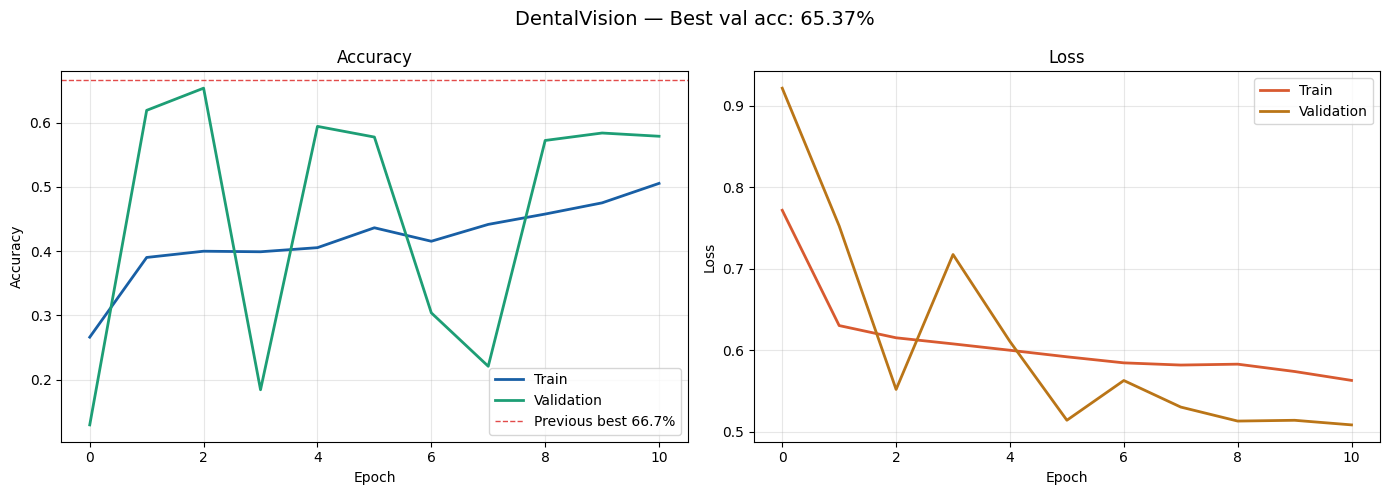

Training curves saved.


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'],     label='Train',      color='#185FA5', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', color='#1D9E75', linewidth=2)
axes[0].axhline(y=0.667, color='#E24B4A', linestyle='--', linewidth=1, label='Previous best 66.7%')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history['loss'],     label='Train',      color='#D85A30', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', color='#BA7517', linewidth=2)
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle(f'DentalVision — Best val acc: {best_val_acc*100:.2f}%', fontsize=14)
plt.tight_layout()
plt.savefig(MODEL_SAVE.replace('.keras', '_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved.')

In [ ]:

test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes                          # no slice

assert len(y_true) == len(y_pred), \
    f'Length mismatch: y_true={len(y_true)}, y_pred={len(y_pred)}'

test_accuracy = np.mean(y_pred == y_true)
print(f'\n=== TEST SET EVALUATION ===')
print(f'Test Accuracy : {test_accuracy*100:.2f}%')
print(f'Total images  : {len(y_true)}')

66/66 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step

=== TEST SET EVALUATION ===
Test Accuracy : 68.24%
Total images  : 2094


In [ ]:

print('\nClassification Report:\n')
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))


Classification Report:

                   precision    recall  f1-score   support

        Bone_Loss      0.000     0.000     0.000       100
           Caries      0.414     0.405     0.410       269
   Impacted_Tooth      0.770     0.962     0.855      1340
    Missing_Teeth      0.265     0.150     0.192       173
Periapical_Lesion      0.143     0.024     0.040       212

         accuracy                          0.682      2094
        macro avg      0.319     0.308     0.299      2094
     weighted avg      0.582     0.682     0.620      2094



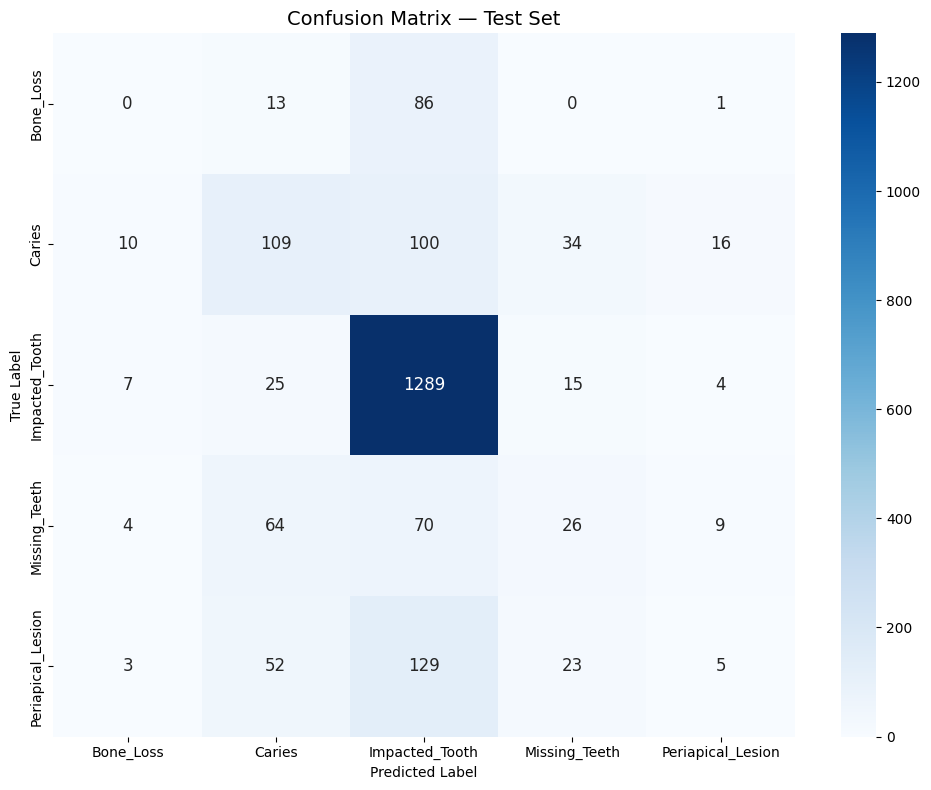

Confusion matrix saved.


In [ ]:

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'size': 12})
plt.title('Confusion Matrix — Test Set', fontsize=14)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved.')

In [ ]:

print('=' * 60)
print('DENTAL VISION — FINAL SUMMARY')
print('=' * 60)
print(f'Model         : {model.name}')
print(f'Parameters    : {model.count_params():,}')
print(f'Best Val Acc  : {best_val_acc*100:.2f}%')
print(f'Test Accuracy : {test_accuracy*100:.2f}%')
print(f'\nTest set class distribution:')
unique, cnts = np.unique(y_true, return_counts=True)
for idx, cnt in zip(unique, cnts):
    print(f'  {class_names[idx]:<25s} {cnt:4d} ({100*cnt/len(y_true):.1f}%)')
print(f'\nFiles saved:')
print(f'  Model           : {MODEL_SAVE}')
print(f'  Class names     : {os.path.join(MODEL_DIR, "class_names.json")}')
print(f'  Training curves : {MODEL_SAVE.replace(".keras", "_curves.png")}')
print(f'  Confusion matrix: {os.path.join(MODEL_DIR, "confusion_matrix.png")}')
print(f'  Training log    : {MODEL_SAVE.replace(".keras", "_log.csv")}')
print('=' * 60)

DENTAL VISION — FINAL SUMMARY
Model         : DentalCNN_ResNet
Parameters    : 12,479,461
Best Val Acc  : 65.37%
Test Accuracy : 68.24%

Test set class distribution:
  Bone_Loss                  100 (4.8%)
  Caries                     269 (12.8%)
  Impacted_Tooth            1340 (64.0%)
  Missing_Teeth              173 (8.3%)
  Periapical_Lesion          212 (10.1%)

Files saved:
  Model           : D:/FYP/dental-vision/ML/Models\dental_model_v3_focal.keras
  Class names     : D:/FYP/dental-vision/ML/Models\class_names.json
  Training curves : D:/FYP/dental-vision/ML/Models\dental_model_v3_focal_curves.png
  Confusion matrix: D:/FYP/dental-vision/ML/Models\confusion_matrix.png
  Training log    : D:/FYP/dental-vision/ML/Models\dental_model_v3_focal_log.csv
